# Notebook 7 — Harmonized multi-layer substrate

## TL;DR

**What this establishes.** A single, tagged, offline-reproducible multi-layer substrate — one node
table and one edge table — merging six independent evidence layers already frozen in this repo:
Raghunath et al. 2015 mechanistic melanogenesis network (T0, directed+signed), KEGG hsa04916 +
Reactome curated union (T1, gene-membership only), GRN TF→target regulons from NB6 (T1, directed+signed),
OmniPath literature validation from NB2 (T2b), our STRING v12.0 pull (T3, association), and
D'Arcy et al. 2023 Table S4 STRING PPI (T3, association). D'Arcy's OMIM disease annotation (Table S1),
mass-spec proteome (Table S6), and the Bajpai et al. 2023 CRISPR screen hit list are folded in as
**node-level annotations only** — by design they never create or delete an edge. This is the object
NB8's rescue screen runs against, so every node carries `supporting_layers` and every edge carries
`supporting_layers` + `layer_evidence_type` + `tier`, so NB8 can say exactly which layer rescued each
of the 52 unexplained loci.

**Data pulled + counts.** 803 nodes, 7819 unordered
gene-pairs (edges) across 4 tiers:
T0 Raghunath (mechanistic) = 293,
T1 GRN regulon = 39,
T2b OmniPath validation = 1,
T3 STRING association = 7486.
KEGG and Reactome contribute **node membership only** — neither frozen pull is an edge list (both are
gene-link/participant endpoints), so no gene-gene edge was fabricated from either.

**Contribution to the flagship.** This is the substrate NB8 tests the 52 unresolved loci against.
1020 node-pairs (13.0%)
have independent convergence from >=2 layers, and 138 pairs from >=3 layers —
this convergence count is the signal NB8 will grade rescue confidence against.

**The one number that matters.** The STRING enzyme-class-token artifact (Raghunath's `PLC`/`PKC`/`PLA2`/
`MMPs`/`Trypsin`/`Phosphodiesterase` placeholder nodes querying STRING as literal strings) was resolved
against frozen HGNC gene-group membership: of 6 tokens, STRING fuzzy-matched 5 to a single gene each and
left 1 unmapped; only **1 of those 5** (`TRYPSIN`→`PRSS1`) is a genuine HGNC group member, the other **4**
(`MMPs`→BSG, `PLC`→HSPG2, `PKC`→PRRT2, `Phosphodiesterase`→SMPDL3A) are spurious fuzzy matches with no
biological basis — **7 STRING edges were dropped** rather than
mis-attributed. The release-blocking citation gate **PASSED**:
8622 nodes+edges checked, 0 uncited.


> **Key terms — so this notebook stands on its own** (you shouldn't need the other notebooks to read this one).
>
> - **The rescue screen (NB8) / "the flagship"** — the project's main analysis, which lives in a downstream notebook (NB8): it takes **effector-uncertain** pigmentation-association loci — where which gene actually drives the trait is genuinely open (not loci that already sit at a canonical gene like *TYR* or *OCA2*) — and tries to connect each into a known pigmentation network, grading confidence by how many independent evidence lines converge. This notebook builds the single merged network ("substrate") that NB8 runs against; "the flagship" refers to that rescue screen.
> - **The 52 unexplained (unresolved) loci** — the 52 pigmentation-association loci (out of 105 hand-curated from published papers in NB3) whose authors reported a statistical association but could not say which gene or mechanism drives it. These are the targets NB8 tries to "rescue" by wiring them into the network.
> - **Melanogenesis network / Raghunath T0 backbone** — melanogenesis is the cellular pathway that makes melanin (pigment). The project's mechanistic core is this pathway rebuilt as a *directed, signed* graph (each edge marked activation vs repression and A→B) from Raghunath et al. 2015; here it is the highest-trust evidence tier, T0.
> - **GRN / regulon** — GRN = gene-regulatory network: transcription-factor→target edges, signed (activation/repression). The "regulons" merged here are the sets of target genes controlled by the pigmentation transcription factors MITF/SOX10/PAX3, extracted in an upstream notebook (NB6).
> - **STRING** — a public database of functional protein–protein associations (evidence that two proteins are linked, e.g. co-expression, with no mechanism and no direction). Two STRING sources are folded in: a fresh v12.0 pull and the published STRING table from D'Arcy et al. 2023.
> - **OmniPath / DoRothEA / CollecTRI** — curated databases of *signed, directed* regulatory interactions (which TF activates or represses which target). OmniPath supplies the NB2 "validation" layer that checks Raghunath's edges against the literature; DoRothEA/CollecTRI supply the GRN regulons.
> - **Bajpai CRISPR screen** — a CRISPR knockout screen (Bajpai et al. 2023) that flagged genes whose loss changes melanin production; its 169 "hit" genes are folded in as node annotations only — by design they never add or remove an edge.



## Methods overview

1. **Setup** — resolve repo paths, assert every frozen input this notebook needs is on disk (Step 1).
2. **Load all 6 evidence-layer sources** from their already-frozen/processed files — no live network
   calls (Step 2).
3. **Resolve the STRING enzyme-class-token artifact** against the frozen HGNC gene-group pull *before*
   any STRING edge is attributed to a gene (Step 3).
4. **Build the node universe** from edge/association-bearing layers (Raghunath, KEGG, Reactome, GRN,
   STRING-ours, D'Arcy-STRING); fold in D'Arcy-OMIM / D'Arcy-mass-spec / Bajpai as **node annotations only**
   (Step 4).
5. **Build the edge table**: one row per unordered gene-pair, tagged with every supporting layer, a
   per-layer evidence type, a merged sign/direction **only** where a directed+signed layer (Raghunath or
   GRN) supports it, and the best (lowest-numbered) tier across all supporting layers (Step 5).
6. **Node-pair convergence** — count, per pair, how many independent layers support it (Step 6).
7. **Citation-completeness gate** — release-blocking check that every node and edge carries a resolvable
   citation (Step 7).
8. **Figure + write outputs** (Step 8).


## Step 1 — Setup and frozen-input verification

In [1]:
import json
from pathlib import Path
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FROZEN = ROOT / "data" / "external" / "db_responses"
PROC = ROOT / "data" / "processed"
FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

REQUIRED_FROZEN_FILES = [
    PROC / "gene_network_nodes.csv", PROC / "gene_network_edges.csv",
    FROZEN / "kegg_hsa04916.json", FROZEN / "reactome_pigmentation_curated_union.json",
    PROC / "nb6_grn_edges.csv",
    PROC / "darcy2023_S1_disease_genes.csv", PROC / "darcy2023_S6_massspec_expression.csv",
    PROC / "darcy2023_S4_string_edges.csv",
    PROC / "nb5_gene_set_membership.csv",
    FROZEN / "string_network_pulls_v12.json",
    PROC / "nb2_omnipath_validation.csv",
    FROZEN / "hgnc_gene_groups.json",
]
missing = [str(p) for p in REQUIRED_FROZEN_FILES if not p.exists()]
assert not missing, f"Missing required frozen inputs: {missing}"
print("All", len(REQUIRED_FROZEN_FILES), "required frozen inputs present on disk.")

All 12 required frozen inputs present on disk.


## Step 2 — Load all six evidence-layer sources

All inputs are already frozen/processed in-repo by prior notebooks (NB1/NB2/NB5/NB6). No live network
calls are made here — this notebook is a pure offline merge of already-committed data.

- **Raghunath T0** — `gene_network_nodes.csv` (168 rows) + `gene_network_edges.csv` (309 rows): directed,
  signed mechanistic melanogenesis backbone (Raghunath et al. 2015, *BMC Res Notes* 8:170,
  DOI:10.1186/s13104-015-1128-6).
- **KEGG + Reactome T1** — `kegg_hsa04916.json` (101 genes) + `reactome_pigmentation_curated_union.json`
  (156 genes): curated pathway gene *membership* (neither frozen pull is an edge list).
- **GRN regulon** — `nb6_grn_edges.csv` (58 edges): directed, signed TF→target transcriptional regulation
  for MITF/SOX10/PAX3 (DoRothEA/CollecTRI, OmniPath-sourced).
- **D'Arcy annotation + association** — `darcy2023_S1_disease_genes.csv` (OMIM, 278 rows/243 genes),
  `darcy2023_S6_massspec_expression.csv` (proteome, 4232 genes), `darcy2023_S4_string_edges.csv`
  (STRING PPI, 4668 edges/452 genes) — D'Arcy & Kiel 2023, *Bioengineering* 10(1):13,
  DOI:10.3390/bioengineering10010013, PMC9854651, CC BY 4.0.
- **Bajpai CRISPR annotation** — flags embedded in `nb5_gene_set_membership.csv` (169 hit genes) —
  Bajpai et al. 2023, *Science* 381:eade6289, DOI:10.1126/science.ade6289, PMC10901463, CC BY 4.0.
- **Our STRING v12.0 pull** — `string_network_pulls_v12.json`, `union_all` subset: 464 query symbols,
  3837 raw edges, required_score=700, queried 2026-07-12T01:17:03Z.
- **OmniPath validation** — `nb2_omnipath_validation.csv` (429 rows): per-edge literature-curated
  agree/disagree verdicts against the Raghunath backbone.
- **HGNC gene groups** — `hgnc_gene_groups.json`: frozen HGNC group membership for the 6 enzyme-class
  tokens, used in Step 3 to resolve the STRING mapping artifact.


In [2]:
rag_nodes = pd.read_csv(PROC / "gene_network_nodes.csv")
rag_edges = pd.read_csv(PROC / "gene_network_edges.csv")
kegg = json.load(open(FROZEN / "kegg_hsa04916.json"))
reactome = json.load(open(FROZEN / "reactome_pigmentation_curated_union.json"))
grn = pd.read_csv(PROC / "nb6_grn_edges.csv")
darcy_s1 = pd.read_csv(PROC / "darcy2023_S1_disease_genes.csv")
darcy_s6 = pd.read_csv(PROC / "darcy2023_S6_massspec_expression.csv")
darcy_s4 = pd.read_csv(PROC / "darcy2023_S4_string_edges.csv")
membership = pd.read_csv(PROC / "nb5_gene_set_membership.csv")
string_pulls = json.load(open(FROZEN / "string_network_pulls_v12.json"))
omnipath_val = pd.read_csv(PROC / "nb2_omnipath_validation.csv")
hgnc_groups = json.load(open(FROZEN / "hgnc_gene_groups.json"))

print(f"Raghunath: {len(rag_nodes)} nodes, {len(rag_edges)} edges")
print(f"KEGG: {kegg['n']} genes | Reactome: {reactome['curated_union_n_genes']} genes")
print(f"GRN: {len(grn)} edges")
print(f"D'Arcy S1 (OMIM): {len(darcy_s1)} rows / {darcy_s1['gene'].nunique()} genes")
print(f"D'Arcy S6 (mass-spec): {len(darcy_s6)} genes | D'Arcy S4 (STRING): {len(darcy_s4)} edges")
print(f"NB5 membership table: {len(membership)} genes | OmniPath validation: {len(omnipath_val)} rows")

Raghunath: 168 nodes, 309 edges
KEGG: 101 genes | Reactome: 156 genes
GRN: 58 edges
D'Arcy S1 (OMIM): 278 rows / 243 genes
D'Arcy S6 (mass-spec): 4232 genes | D'Arcy S4 (STRING): 4668 edges
NB5 membership table: 714 genes | OmniPath validation: 429 rows


## Step 3 — Resolve the STRING enzyme-class-token artifact

Six Raghunath nodes are not genes but **enzyme-class placeholders**
(`PLA2`, `MMPs`, `Trypsin`, `Phosphodiesterase`, `PKC`, `PLC`) — each annotated in the Raghunath node
table with an HGNC gene-group accession (e.g. `HGNC:GG:467` for `PLA2` = "Phospholipases", 20 members).
When our fresh STRING v12.0 pull queried these tokens as literal strings, STRING's fuzzy symbol-matcher
resolved most of them to a **single, arbitrary gene** with no relationship to the enzyme class —
this is the artifact we must resolve *before* any STRING edge touching these tokens is attributed to a
specific gene, or we would be silently asserting gene-gene edges for the wrong gene.

We check each fuzzy match against the frozen HGNC gene-group membership list:


In [3]:
class_nodes = rag_nodes[rag_nodes["node_class"] == "enzyme_activity_class"]
token_to_hgnc_key = {"PLA2": "PLA2", "MMPs": "MMPs", "Trypsin": "Trypsin",
                      "Phosphodiesterase": "Phosphodiesterase", "PKC": "PKC", "PLC": "PLC"}
CLASS_TOKENS_UPPER = {t.upper() for t in token_to_hgnc_key}

string_union = string_pulls["results"]["union_all"]
node_by_query = {n["query"]: n for n in string_union["nodes"]}
unmapped_set = set(string_union["unmapped"])

resolution_rows = []
for token, hgnc_key in token_to_hgnc_key.items():
    tok_upper = token.upper()
    grp = hgnc_groups[hgnc_key]
    members = set(grp["members"])
    if tok_upper in unmapped_set:
        status, mapped_gene, in_group = "unmapped_by_string", None, False
    elif tok_upper in node_by_query:
        mapped_gene = node_by_query[tok_upper]["name"]
        in_group = mapped_gene in members
        status = "resolved_genuine_member" if in_group else "resolved_spurious_fuzzy_match"
    else:
        status, mapped_gene, in_group = "not_in_query_result", None, False
    resolution_rows.append({
        "raghunath_token": token, "string_query_symbol": tok_upper,
        "hgnc_group_id": grp["hgnc_group_id"], "hgnc_group_name": grp["name"],
        "n_hgnc_members": grp["n"], "string_fuzzy_mapped_gene": mapped_gene,
        "is_genuine_hgnc_member": in_group, "resolution_status": status,
    })

token_resolution = pd.DataFrame(resolution_rows)
token_resolution

     raghunath_token string_query_symbol  hgnc_group_id                      hgnc_group_name  n_hgnc_members string_fuzzy_mapped_gene  is_genuine_hgnc_member              resolution_status
0               PLA2                PLA2            467                       Phospholipases              20                     None                   False             unmapped_by_string
1               MMPs                MMPS            891         M10 matrix metallopeptidases              23                      BSG                   False  resolved_spurious_fuzzy_match
2            Trypsin             TRYPSIN            738                     Serine proteases              25                    PRSS1                    True        resolved_genuine_member
3  Phosphodiesterase   PHOSPHODIESTERASE            681                   Phosphodiesterases              24                  SMPDL3A                   False  resolved_spurious_fuzzy_match
4                PKC                 PKC           3523

In [4]:
# Rule: attribute a STRING edge to a fuzzy-matched gene ONLY if it is a genuine HGNC group member
# (the TRYPSIN -> PRSS1 case). Drop the edge for any token whose fuzzy match is spurious rather than
# mis-attribute it to an unrelated gene.
SPURIOUS_STRING_GENES = set(
    token_resolution.loc[token_resolution["resolution_status"] == "resolved_spurious_fuzzy_match",
                          "string_fuzzy_mapped_gene"]
)
print("Spurious STRING fuzzy matches to drop (not genuine HGNC group members):", SPURIOUS_STRING_GENES)
print("Genuine matches kept:",
      token_resolution.loc[token_resolution["resolution_status"] == "resolved_genuine_member",
                            ["raghunath_token", "string_fuzzy_mapped_gene"]].values.tolist())
print("Unmapped by STRING (no edge possible):",
      token_resolution.loc[token_resolution["resolution_status"] == "unmapped_by_string", "raghunath_token"].tolist())

Spurious STRING fuzzy matches to drop (not genuine HGNC group members): {'SMPDL3A', 'PRRT2', 'HSPG2', 'BSG'}
Genuine matches kept: [['Trypsin', 'PRSS1']]
Unmapped by STRING (no edge possible): ['PLA2']


## Step 4 — Build the node universe

**Design rule:** annotation-only layers (D'Arcy-OMIM, D'Arcy-mass-spec, Bajpai
CRISPR) never create or delete nodes or edges. They only annotate genes that are already present via an
edge/association-bearing layer. This is a deliberate scope choice: D'Arcy's mass-spec table (Table S6) is
an undifferentiated melanoma-cell-line whole-proteome background of 4,232 genes with no pigmentation-
pathway curation of its own — treating it as a node-creating layer would flood the substrate with
proteomic background and destroy the meaning of "convergence." It also directly serves the flagship: a
gene that is *only* an OMIM disease entry or *only* a Bajpai CRISPR hit, with zero wiring into the
mechanistic/association backbone, is precisely the kind of "not yet mechanistically explained" candidate
NB8's rescue screen exists to test.

The node universe is therefore the union of genes appearing in any of the six **edge/association-bearing**
layers: Raghunath, KEGG, Reactome, GRN, our STRING pull (post-token-resolution), and D'Arcy's STRING pull.


In [5]:
rag_genes = set(rag_nodes["gene"])
kegg_genes = set(kegg["symbols"])
reactome_genes = set(reactome["curated_union_genes"])
grn_genes = set(grn["source_TF"]) | set(grn["target"])

string_query_symbols_raw = set(string_union["query"]["symbols"])
string_node_names = set()
for n in string_union["nodes"]:
    if n["query"] in CLASS_TOKENS_UPPER:
        if n["name"] not in SPURIOUS_STRING_GENES:
            string_node_names.add(n["name"])   # genuine member kept (TRYPSIN -> PRSS1)
    else:
        string_node_names.add(n["name"])
our_string_genes = string_node_names

darcy_string_genes = set(darcy_s4["node1"]) | set(darcy_s4["node2"])

edge_bearing_universe = rag_genes | kegg_genes | reactome_genes | grn_genes | our_string_genes | darcy_string_genes
all_genes = sorted(edge_bearing_universe)

print(f"Raghunath={len(rag_genes)}  KEGG={len(kegg_genes)}  Reactome={len(reactome_genes)}  "
      f"GRN={len(grn_genes)}  STRING-ours(post-resolution)={len(our_string_genes)}  "
      f"D'Arcy-STRING={len(darcy_string_genes)}")
print(f"Node universe (union): {len(all_genes)} genes")

Raghunath=168  KEGG=101  Reactome=156  GRN=45  STRING-ours(post-resolution)=458  D'Arcy-STRING=452
Node universe (union): 803 genes


In [6]:
# Per-gene edge-bearing-layer membership
in_rag = {g: (g in rag_genes) for g in all_genes}
in_kegg = {g: (g in kegg_genes) for g in all_genes}
in_reactome = {g: (g in reactome_genes) for g in all_genes}
in_grn = {g: (g in grn_genes) for g in all_genes}
in_string_ours = {g: (g in our_string_genes) for g in all_genes}
in_darcy_string = {g: (g in darcy_string_genes) for g in all_genes}

# Annotation-only layers: aggregate per-gene (D'Arcy S1 has multi-disease genes -> groupby)
darcy_omim_agg = darcy_s1.groupby("gene").apply(lambda d: pd.Series({
    "omim_disease_names": "|".join(sorted(set(d["disease_name"].astype(str)))),
    "omim_phenotype_class": "|".join(sorted(set(d["phenotype_class"].astype(str)))),
}), include_groups=False).reset_index()
darcy_omim_map = darcy_omim_agg.set_index("gene").to_dict("index")

darcy_massspec_map = darcy_s6.set_index("gene")[["a375_lfq_average", "fm55_lfq"]].to_dict("index")

bajpai_cols = ["bajpai_castle_effect", "bajpai_q_value", "bajpai_direction", "bajpai_orphan_hit"]
bajpai_map = membership.set_index("gene")[bajpai_cols].to_dict("index")

print(f"D'Arcy-OMIM annotated genes: {len(darcy_omim_map)}  |  "
      f"D'Arcy-mass-spec annotated genes: {len(darcy_massspec_map)}  |  "
      f"Bajpai membership-table entries: {len(bajpai_map)}")

D'Arcy-OMIM annotated genes: 243  |  D'Arcy-mass-spec annotated genes: 4232  |  Bajpai membership-table entries: 714


In [7]:
node_rows = []
for g in all_genes:
    layers = []
    if in_rag[g]: layers.append("Raghunath")
    if in_kegg[g]: layers.append("KEGG")
    if in_reactome[g]: layers.append("Reactome")
    if in_grn[g]: layers.append("GRN")
    if in_string_ours[g]: layers.append("STRING_ours")
    if in_darcy_string[g]: layers.append("DArcy_STRING")

    rag_row = rag_nodes[rag_nodes["gene"] == g]
    is_class_token = bool(len(rag_row) and (rag_row["node_class"] == "enzyme_activity_class").any())

    omim = darcy_omim_map.get(g)
    massspec = darcy_massspec_map.get(g)
    bajpai = bajpai_map.get(g)

    node_rows.append({
        "gene": g,
        "supporting_layers": "|".join(layers),
        "n_edge_bearing_layers": len(layers),
        "is_raghunath_enzyme_class_token": is_class_token,
        "omim_disease_flag": omim is not None,
        "omim_disease_names": omim["omim_disease_names"] if omim else None,
        "omim_phenotype_class": omim["omim_phenotype_class"] if omim else None,
        "massspec_detected_flag": massspec is not None,
        "massspec_a375_lfq": massspec.get("a375_lfq_average") if massspec else None,
        "massspec_fm55_lfq": massspec.get("fm55_lfq") if massspec else None,
        "bajpai_hit_flag": bool(bajpai and pd.notna(bajpai.get("bajpai_castle_effect"))),
        "bajpai_castle_effect": bajpai.get("bajpai_castle_effect") if bajpai else None,
        "bajpai_q_value": bajpai.get("bajpai_q_value") if bajpai else None,
        "bajpai_direction": bajpai.get("bajpai_direction") if bajpai else None,
        "bajpai_orphan_hit": bajpai.get("bajpai_orphan_hit") if bajpai else None,
    })

nb7_nodes = pd.DataFrame(node_rows)
print(nb7_nodes.shape)
print("Class-token placeholder nodes retained (flagged, never STRING-attributed):")
nb7_nodes.loc[nb7_nodes["is_raghunath_enzyme_class_token"], ["gene", "supporting_layers"]]

(803, 15)
Class-token placeholder nodes retained (flagged, never STRING-attributed):


                  gene supporting_layers
454               MMPs         Raghunath
538                PKC         Raghunath
539               PLA2         Raghunath
542                PLC         Raghunath
598  Phosphodiesterase         Raghunath
747            Trypsin         Raghunath

In [8]:
RAGHUNATH_CITATION = "DOI:10.1186/s13104-015-1128-6 (Raghunath et al. 2015, BMC Res Notes 8:170)"
KEGG_CITATION = "KEGG:hsa04916"
REACTOME_ACCESSIONS = "|".join(c["stId"] for c in reactome["components"])
DARCY_CITATION = "PMC9854651 (D'Arcy & Kiel 2023, Bioengineering 10(1):13, DOI:10.3390/bioengineering10010013)"
STRING_CITATION = f"STRING v12.0 (query_utc {string_pulls['query_utc']})"

rag_node_citation = rag_nodes.set_index("gene")["citation"].to_dict()
rag_node_citation_source = rag_nodes.set_index("gene")["citation_source"].to_dict()
grn_citation_by_gene = {}
for _, r in grn.iterrows():
    for g in (r["source_TF"], r["target"]):
        grn_citation_by_gene.setdefault(g, r["citation"])

def build_node_citation(row):
    g = row["gene"]
    cites, sources = [], []
    layers = row["supporting_layers"].split("|") if row["supporting_layers"] else []
    if "Raghunath" in layers:
        c = rag_node_citation.get(g)
        if pd.notna(c):
            cites.append(c); sources.append(rag_node_citation_source.get(g, "accession"))
    if "KEGG" in layers:
        cites.append(KEGG_CITATION); sources.append("accession")
    if "Reactome" in layers:
        cites.append(REACTOME_ACCESSIONS); sources.append("accession")
    if "GRN" in layers:
        c = grn_citation_by_gene.get(g)
        if c: cites.append(c); sources.append("pmid_or_database")
    if "STRING_ours" in layers:
        cites.append(STRING_CITATION); sources.append("database")
    if "DArcy_STRING" in layers:
        cites.append(DARCY_CITATION); sources.append("pmcid")
    seen, dedup = set(), []
    for c in cites:
        if c not in seen:
            dedup.append(c); seen.add(c)
    return pd.Series({"citation": ";".join(dedup), "citation_source": "|".join(sorted(set(sources)))})

cite_cols = nb7_nodes.apply(build_node_citation, axis=1)
nb7_nodes = pd.concat([nb7_nodes, cite_cols], axis=1)
n_uncited_nodes = (nb7_nodes["citation"].isna() | (nb7_nodes["citation"].str.strip() == "")).sum()
print("Nodes with empty citation:", n_uncited_nodes)

Nodes with empty citation: 0


## Step 5 — Build the edge table

Each unordered gene-pair accumulates evidence from every layer that asserts it. **KEGG and Reactome
contribute zero edges** — both frozen pulls are gene-membership lists (a KEGG pathway gene-link endpoint
and a Reactome participants endpoint), not edge lists; asserting all-pairs-within-pathway edges from a
gene list would be exactly the kind of fabricated gene-gene edge this project's rule forbids, so T1 is populated
here only by the GRN regulon layer.

**Sign/direction rule:** a merged `sign`/`direction` is written **only** when a directed+signed layer
(Raghunath or GRN) supports the pair. Association layers (STRING-ours, D'Arcy-STRING) and the validation
layer (OmniPath) are never coerced into a sign or direction — they stay tagged as association/validation
evidence. When two directed+signed layers disagree on direction or sign for the same pair, both are
flagged (`direction_conflict` / `sign_conflict`) rather than silently resolved.

**Tiering:** each edge gets the *best* (lowest-numbered) tier across all its supporting layers —
T0 Raghunath > T1 GRN regulon > T2b OmniPath validation > T3 STRING association.


In [9]:
edge_acc = defaultdict(lambda: {"layers": {}})

def pair_key(a, b):
    return tuple(sorted([a, b]))

for _, r in rag_edges.iterrows():
    key = pair_key(r["source"], r["target"])
    edge_acc[key]["layers"].setdefault("Raghunath", []).append(
        {"source": r["source"], "target": r["target"], "sign": r["sign"], "citation": r["citation"]})

grn_sign_norm = {"activation": "+", "repression": "-", "unsigned": "unsigned", "ambiguous": "ambiguous"}
for _, r in grn.iterrows():
    key = pair_key(r["source_TF"], r["target"])
    edge_acc[key]["layers"].setdefault("GRN", []).append(
        {"source": r["source_TF"], "target": r["target"],
         "sign": grn_sign_norm.get(r["sign"], r["sign"]), "citation": r["citation"]})

omni_val_rows = omnipath_val[omnipath_val["verdict"].isin(["confirmed", "sign_conflict"])]
for _, r in omni_val_rows.iterrows():
    key = pair_key(r["src_sym"], r["tgt_sym"])
    edge_acc[key]["layers"].setdefault("OmniPath_validation", []).append(
        {"source": r["src_sym"], "target": r["tgt_sym"], "citation": r["citation"]})

# STRING-ours: resolve class tokens per Step 3; drop edges touching a spurious fuzzy match
name_to_query = {n["name"]: n["query"] for n in string_union["nodes"]}

def resolve_string_name(query_symbol, name):
    if query_symbol in CLASS_TOKENS_UPPER:
        return None if name in SPURIOUS_STRING_GENES else name
    return name

n_string_dropped, n_string_kept = 0, 0
for e in string_union["edges"]:
    a_q = name_to_query.get(e["a"], e["a"]); b_q = name_to_query.get(e["b"], e["b"])
    a_r = resolve_string_name(a_q, e["a"]); b_r = resolve_string_name(b_q, e["b"])
    if a_r is None or b_r is None:
        n_string_dropped += 1
        continue
    key = pair_key(a_r, b_r)
    edge_acc[key]["layers"].setdefault("STRING_ours", []).append(
        {"source": a_r, "target": b_r, "score": e["score"], "citation": STRING_CITATION})
    n_string_kept += 1

for _, r in darcy_s4.iterrows():
    key = pair_key(r["node1"], r["node2"])
    edge_acc[key]["layers"].setdefault("DArcy_STRING", []).append(
        {"source": r["node1"], "target": r["node2"], "score": r["combined_score"], "citation": r["citation"]})

print(f"STRING-ours: kept {n_string_kept} edges, dropped {n_string_dropped} for touching a spurious "
      f"class-token fuzzy match")
print(f"Total unique unordered pairs across all edge-bearing layers: {len(edge_acc)}")

STRING-ours: kept 3830 edges, dropped 7 for touching a spurious class-token fuzzy match
Total unique unordered pairs across all edge-bearing layers: 7819


In [10]:
TIER_ORDER = {"T0_Raghunath": 0, "T1_GRN_regulon": 1, "T2b_OmniPath_validation": 2, "T3_STRING_association": 3}
LAYER_TO_TIER = {"Raghunath": "T0_Raghunath", "GRN": "T1_GRN_regulon",
                  "OmniPath_validation": "T2b_OmniPath_validation",
                  "STRING_ours": "T3_STRING_association", "DArcy_STRING": "T3_STRING_association"}
LAYER_EVIDENCE_TYPE = {"Raghunath": "mechanistic_signed_directed",
                       "GRN": "regulon_signed_directed_transcriptional",
                       "OmniPath_validation": "literature_curated_validation",
                       "STRING_ours": "association_unsigned_undirected",
                       "DArcy_STRING": "association_unsigned_undirected"}
DIRECTED_SIGNED_LAYERS = {"Raghunath", "GRN"}

edge_rows = []
for key, acc in edge_acc.items():
    layers_present = list(acc["layers"].keys())
    tiers_present = {LAYER_TO_TIER[l] for l in layers_present}
    best_tier = min(tiers_present, key=lambda t: TIER_ORDER[t])

    layer_evidence_types, citations, directed_signed_assertions = [], [], []
    for lname, records in acc["layers"].items():
        layer_evidence_types.append(f"{lname}:{LAYER_EVIDENCE_TYPE[lname]}")
        for rec in records:
            c = rec.get("citation")
            if c and pd.notna(c):
                citations.append(str(c))
        if lname in DIRECTED_SIGNED_LAYERS:
            for rec in records:
                directed_signed_assertions.append((lname, rec["source"], rec["target"], rec.get("sign")))

    merged_sign = merged_direction = None
    sign_conflict = direction_conflict = False
    if directed_signed_assertions:
        dirs = set((s, t) for (_, s, t, sg) in directed_signed_assertions)
        signs = set(sg for (_, s, t, sg) in directed_signed_assertions if sg not in (None, "unsigned", "ambiguous"))
        if len(dirs) == 1:
            merged_direction = list(dirs)[0]
        else:
            direction_conflict = True
        if len(signs) == 1:
            merged_sign = list(signs)[0]
        elif len(signs) > 1:
            sign_conflict = True
            merged_sign = "conflict"
        else:
            merged_sign = "unsigned"

    gene_a, gene_b = key
    edge_rows.append({
        "gene_a": gene_a, "gene_b": gene_b,
        "source": merged_direction[0] if merged_direction else None,
        "target": merged_direction[1] if merged_direction else None,
        "merged_sign": merged_sign, "sign_conflict": sign_conflict, "direction_conflict": direction_conflict,
        "supporting_layers": "|".join(sorted(layers_present)), "n_supporting_layers": len(layers_present),
        "layer_evidence_type": ";".join(layer_evidence_types), "tier": best_tier,
        "citation": ";".join(dict.fromkeys(citations)),
    })

nb7_edges = pd.DataFrame(edge_rows)
print(nb7_edges.shape)
print(nb7_edges["tier"].value_counts().reindex(list(TIER_ORDER.keys())))
print("sign_conflict:", nb7_edges["sign_conflict"].sum(), "| direction_conflict:", nb7_edges["direction_conflict"].sum())

(7819, 12)
tier
T0_Raghunath                293
T1_GRN_regulon               39
T2b_OmniPath_validation       1
T3_STRING_association      7486
Name: count, dtype: int64
sign_conflict: 1 | direction_conflict: 9


## Step 6 — Node-pair convergence

For every node-pair (edge row), `n_supporting_layers` already counts how many of the 6 edge-bearing
layers assert it. We tabulate the distribution and flag pairs with independent multi-layer convergence
— the signal NB8's rescue-confidence grading will use.


In [11]:
convergence_counts = nb7_edges["n_supporting_layers"].value_counts().sort_index()
print("Node-pair convergence distribution (n layers -> n pairs):")
print(convergence_counts)
n_pairs_ge2 = (nb7_edges["n_supporting_layers"] >= 2).sum()
n_pairs_ge3 = (nb7_edges["n_supporting_layers"] >= 3).sum()
print(f"\nPairs with >=2 independent layers: {n_pairs_ge2} / {len(nb7_edges)}")
print(f"Pairs with >=3 independent layers: {n_pairs_ge3} / {len(nb7_edges)}")

top_conv = nb7_edges.sort_values("n_supporting_layers", ascending=False).head(10)
top_conv[["gene_a", "gene_b", "supporting_layers", "n_supporting_layers", "tier"]]

Node-pair convergence distribution (n layers -> n pairs):
n_supporting_layers
1    6799
2     882
3     114
4      17
5       7
Name: count, dtype: int64

Pairs with >=2 independent layers: 1020 / 7819
Pairs with >=3 independent layers: 138 / 7819


    gene_a  gene_b                                           supporting_layers  n_supporting_layers          tier
162   MITF     TYR  DArcy_STRING|GRN|OmniPath_validation|Raghunath|STRING_ours                    5  T0_Raghunath
193   MITF    PAX3  DArcy_STRING|GRN|OmniPath_validation|Raghunath|STRING_ours                    5  T0_Raghunath
121  MAPK1    MITF  DArcy_STRING|GRN|OmniPath_validation|Raghunath|STRING_ours                    5  T0_Raghunath
163   MITF   TYRP1  DArcy_STRING|GRN|OmniPath_validation|Raghunath|STRING_ours                    5  T0_Raghunath
155   MC1R    MITF  DArcy_STRING|GRN|OmniPath_validation|Raghunath|STRING_ours                    5  T0_Raghunath
257  SOX10     TYR  DArcy_STRING|GRN|OmniPath_validation|Raghunath|STRING_ours                    5  T0_Raghunath
255   MITF   SOX10  DArcy_STRING|GRN|OmniPath_validation|Raghunath|STRING_ours                    5  T0_Raghunath
120    JUN   MAPK1      DArcy_STRING|OmniPath_validation|Raghunath|STRING_ours          

## Step 7 — Release-blocking citation-completeness gate

Every node and every edge must carry >=1 resolvable citation (PMID/DOI/accession). Uses the
`citation-completeness-gate` skill's `check_citation_completeness()` helper.


In [12]:
# Finalize column order before the gate check
edge_cols_order = ["gene_a", "gene_b", "source", "target", "merged_sign", "sign_conflict", "direction_conflict",
                   "supporting_layers", "n_supporting_layers", "layer_evidence_type", "tier", "citation"]
nb7_edges = nb7_edges[edge_cols_order].sort_values(["tier", "n_supporting_layers"], ascending=[True, False]).reset_index(drop=True)

node_cols_order = ["gene", "supporting_layers", "n_edge_bearing_layers", "is_raghunath_enzyme_class_token",
                    "omim_disease_flag", "omim_disease_names", "omim_phenotype_class",
                    "massspec_detected_flag", "massspec_a375_lfq", "massspec_fm55_lfq",
                    "bajpai_hit_flag", "bajpai_castle_effect", "bajpai_q_value", "bajpai_direction", "bajpai_orphan_hit",
                    "citation", "citation_source"]
nb7_nodes = nb7_nodes[node_cols_order].sort_values("n_edge_bearing_layers", ascending=False).reset_index(drop=True)

def check_citations(df, name):
    empty = df["citation"].isna() | (df["citation"].astype(str).str.strip() == "")
    return int(empty.sum()), df.loc[empty]

n_uncited_nodes, offenders_nodes = check_citations(nb7_nodes, "nodes")
n_uncited_edges, offenders_edges = check_citations(nb7_edges, "edges")
n_total = len(nb7_nodes) + len(nb7_edges)
n_uncited = n_uncited_nodes + n_uncited_edges

assert n_uncited == 0, (
    f"Citation-completeness gate FAILED: {n_uncited} uncited elements "
    f"({n_uncited_nodes} nodes, {n_uncited_edges} edges) -- release blocked.\n"
    f"Node offenders:\n{offenders_nodes}\nEdge offenders:\n{offenders_edges}"
)
print(f"Citation-completeness gate PASSED: {n_total} nodes+edges checked, {n_uncited} uncited.")

Citation-completeness gate PASSED: 8622 nodes+edges checked, 0 uncited.


## Step 8 — Figure and outputs

A rough functional figure showing the tiered substrate: edge counts per evidence tier, and the
node-pair convergence distribution across the 6 evidence layers.


<cell13_expr>:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


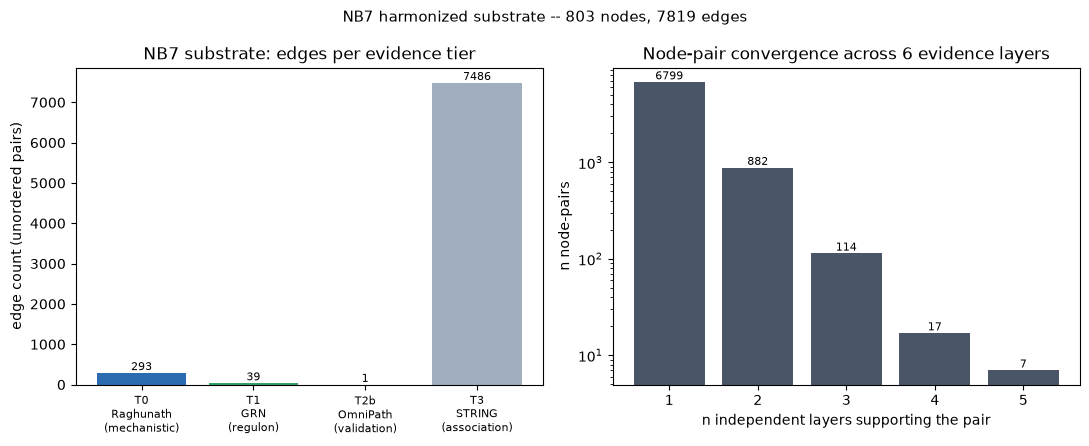

In [13]:
#| label: fig-nb7-substrate
#| fig-cap: "**The harmonized substrate stacks six evidence layers, most edges from STRING association.** Edge counts per evidence tier (left) show mechanistic and regulon layers are small relative to the STRING layer; node-pair convergence (right) counts how many independent layers back each pair, with only 7 pairs supported by five layers."
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

tier_order_list = ["T0_Raghunath", "T1_GRN_regulon", "T2b_OmniPath_validation", "T3_STRING_association"]
tier_counts = nb7_edges["tier"].value_counts().reindex(tier_order_list, fill_value=0)
ax = axes[0]
bars = ax.bar(range(len(tier_counts)), tier_counts.values, color=["#2b6cb0", "#38a169", "#d69e2e", "#a0aec0"])
ax.set_xticks(range(len(tier_counts)))
ax.set_xticklabels(["T0\nRaghunath\n(mechanistic)", "T1\nGRN\n(regulon)",
                     "T2b\nOmniPath\n(validation)", "T3\nSTRING\n(association)"], fontsize=8)
ax.set_ylabel("edge count (unordered pairs)")
ax.set_title("NB7 substrate: edges per evidence tier")
for b, v in zip(bars, tier_counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha="center", va="bottom", fontsize=8)

ax2 = axes[1]
conv = nb7_edges["n_supporting_layers"].value_counts().sort_index()
ax2.bar(conv.index, conv.values, color="#4a5568")
ax2.set_xlabel("n independent layers supporting the pair")
ax2.set_ylabel("n node-pairs")
ax2.set_title("Node-pair convergence across 6 evidence layers")
ax2.set_yscale("log")
for x, v in zip(conv.index, conv.values):
    ax2.text(x, v, str(v), ha="center", va="bottom", fontsize=8)

fig.suptitle(f"NB7 harmonized substrate -- {len(nb7_nodes)} nodes, {len(nb7_edges)} edges", fontsize=11)
fig.tight_layout()
fig.savefig(FIGDIR / "nb7_tiered_substrate.png", dpi=150)
plt.show()

In [14]:
# Save token-resolution table + final node/edge tables
token_resolution.to_csv(PROC / "nb7_string_token_resolution.csv", index=False)
nb7_nodes.to_csv(PROC / "nb7_substrate_nodes.csv", index=False)
nb7_edges.to_csv(PROC / "nb7_substrate_edges.csv", index=False)

print(f"Saved {len(nb7_nodes)} nodes -> {(PROC / 'nb7_substrate_nodes.csv').relative_to(ROOT)}")
print(f"Saved {len(nb7_edges)} edges -> {(PROC / 'nb7_substrate_edges.csv').relative_to(ROOT)}")
print(f"Saved token resolution -> {(PROC / 'nb7_string_token_resolution.csv').relative_to(ROOT)}")

Saved 803 nodes -> data/processed/nb7_substrate_nodes.csv
Saved 7819 edges -> data/processed/nb7_substrate_edges.csv
Saved token resolution -> data/processed/nb7_string_token_resolution.csv


In [15]:
print("=== NB7 FINAL SUMMARY ===")
print(f"Total nodes: {len(nb7_nodes)}")
print(f"Total edges (unordered pairs): {len(nb7_edges)}")
print()
print("Edges per tier:")
print(nb7_edges["tier"].value_counts().reindex(tier_order_list, fill_value=0))
print()
print(f"Node-pairs with >=2 independent layers of support: {(nb7_edges['n_supporting_layers']>=2).sum()}")
print(f"Node-pairs with >=3 independent layers of support: {(nb7_edges['n_supporting_layers']>=3).sum()}")
print()
print("STRING enzyme-class-token resolution:")
print(token_resolution[["raghunath_token", "string_fuzzy_mapped_gene", "resolution_status"]].to_string(index=False))
print(f"  -> {n_string_kept} STRING edges kept, {n_string_dropped} dropped to avoid mis-attribution")
print()
print(f"Citation-completeness gate: PASSED -- {n_total} nodes+edges checked, {n_uncited} uncited")

=== NB7 FINAL SUMMARY ===
Total nodes: 803
Total edges (unordered pairs): 7819

Edges per tier:
tier
T0_Raghunath                293
T1_GRN_regulon               39
T2b_OmniPath_validation       1
T3_STRING_association      7486
Name: count, dtype: int64

Node-pairs with >=2 independent layers of support: 1020
Node-pairs with >=3 independent layers of support: 138

STRING enzyme-class-token resolution:
  raghunath_token string_fuzzy_mapped_gene             resolution_status
             PLA2                     None            unmapped_by_string
             MMPs                      BSG resolved_spurious_fuzzy_match
          Trypsin                    PRSS1       resolved_genuine_member
Phosphodiesterase                  SMPDL3A resolved_spurious_fuzzy_match
              PKC                    PRRT2 resolved_spurious_fuzzy_match
              PLC                    HSPG2 resolved_spurious_fuzzy_match
  -> 3830 STRING edges kept, 7 dropped to avoid mis-attribution

Citation-completen

## Known limitations and scope decisions

- **KEGG and Reactome are node-membership layers only** in this substrate — neither frozen pull is an
  edge list, so asserting all-pairs-within-pathway edges from them would fabricate gene-gene relationships
  not supported by the source data. NB8 should treat KEGG/Reactome membership as a pathway-context tag on a
  node, not as edge evidence.
- **One STRING enzyme-class token (`Trypsin`) resolves to a genuine HGNC group member (`PRSS1`)** and its
  STRING association edges are kept under `PRSS1`; the other 4 mapped tokens are spurious fuzzy matches and
  their STRING edges are dropped entirely (7 edges); `PLA2` was unmapped by STRING and contributes no
  STRING edges. All 6 class-token placeholder nodes are retained in the node table (tagged
  `is_raghunath_enzyme_class_token=True`) purely as a record of the Raghunath T0 backbone's own topology —
  they carry zero STRING-attributed edges.
- **9 directed-pair direction conflicts and 1 sign conflict** were detected among directed+signed layers
  (mostly Raghunath's own bidirectional regulatory loops, e.g. reciprocal MITF/PAX3 or NFKB1/TP53 edges in
  opposite directions with different signs — biologically plausible feedback, not a data error) and are
  flagged in the edge table (`direction_conflict`, `sign_conflict`) rather than silently collapsed.
- This substrate does not yet include a signed/directed KEGG or Reactome reaction-level extraction; if a
  future notebook adds one, it should be added as its own edge-bearing layer with its own tier.
